# Pandas & Matplotlib Bilgi Testi

## Hazırlık**Soru 0:** `pandas`'ı `pd`, `numpy`'ı `np`, `matplotlib.pyplot`'u `plt` takma adıyla içe aktarın.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

---## Bölüm 1 — Series**Soru 1.1:** Bir kırtasiyedeki ürünlerin stok adetlerini tutan bir Series oluşturun: index = `['Kalem','Defter','Silgi','Cetvel']`, değerler = `[300, 150, 80, 45]`.**Soru 1.2:** `'Silgi'` ürününün stok adedini index adıyla seçip yazdırın.**Soru 1.3:** Stoğu en az olan ürünü `.idxmin()` ile bulun.**Soru 1.4:** Tüm ürünlerin toplam stok adedini `.sum()` ile hesaplayın.

In [2]:
veri= pd.Series([300, 150, 80, 45], ['Kalem','Defter','Silgi','Cetvel'])
print(veri['Silgi'])

80


In [3]:
veri.idxmin(axis=0)

'Cetvel'

In [4]:
int(veri.sum())

575

---## Bölüm 2 — DataFrame Oluşturma**Soru 2.1:** Bir spor salonundaki üyeleri temsil eden, `uye_adi`, `paket_turu` (örn. Aylık, Yıllık) ve `odenen_tutar` sütunlarından oluşan, en az 5 satırlık bir DataFrame oluşturun.**Soru 2.2:** `.shape` ile kaç üye ve kaç bilgi sütunu olduğunu kontrol edin.**Soru 2.3:** `.columns` ile sütun isimlerini listeleyin.

In [5]:
data={
  "uye_adi" : ["ali","veli","mehmet","hasan","berke"],
  "paket_turu" : ["aylik", "yillik","aylik", "yillik","yillik"],
  "odenen_tutar" : [120, 1000, 95, 1100, 850]
}
df=pd.DataFrame(data)

In [6]:
print(df.shape, df.columns)

(5, 3) Index(['uye_adi', 'paket_turu', 'odenen_tutar'], dtype='object')


---## Bölüm 3 — CSV/Excel Okuma (Kavramsal)Gerçek bir dosyanız olmasa da sözdizimini test edelim.**Soru 3.1:** `"satislar.csv"` adlı bir dosyayı okuyup `df_csv` değişkenine atayan kodu yazın (dosya olmadığı için hata verecektir, bu normaldir — sadece doğru sözdizimini yazın).**Soru 3.2:** `"rapor.xlsx"` adlı bir Excel dosyasını okuyup `df_excel` değişkenine atayan kodu yazın.

In [7]:
#df_csv = pd.read_csv("satislar.csv")
#df_excel = pd.read_excel("rapor.xlsx")

---## Bölüm 4 — Veriyi İncelemeAşağıdaki hücreyi çalıştırarak bir e-ticaret sipariş verisi oluşturun:

In [8]:
df = pd.DataFrame({"siparis_no": [1001, 1002, 1003, 1004, 1005, 1006, 1007],    "kargo_suresi": [2, 5, 3, np.nan, 1, 4, 6],    "urun_adedi": [1, 3, 2, 5, 1, 2, 4],    "toplam_tutar": [150.0, 480.5, 220.0, 610.0, 90.0, 310.0, 720.0]})

**Soru 4.1:** `.head(3)` ve `.tail(2)` ile ilk 3 ve son 2 siparişi görüntüleyin.**Soru 4.2:** `.info()` ile hangi sütunda eksik veri olduğunu tespit edin.**Soru 4.3:** `.describe()` ile kargo süresi, ürün adedi ve toplam tutarın istatistiklerini inceleyin.

In [9]:
#df.head(3)
#df.tail(2)
#df.info()
df.describe()

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar
count,7.000000,6.000000,7.000000,7.000000
mean,1004.000000,3.500000,2.571429,368.642857
std,2.160247,1.870829,1.511858,239.860153
min,1001.000000,1.000000,1.000000,90.000000
25%,1002.500000,2.250000,1.500000,185.000000
50%,1004.000000,3.500000,2.000000,310.000000
75%,1005.500000,4.750000,3.500000,545.250000
max,1007.000000,6.000000,5.000000,720.000000


---## Bölüm 5 — Sütun ve Satır SeçmeYukarıdaki sipariş `df`'ini kullanarak:**Soru 5.1:** Sadece `siparis_no` ve `toplam_tutar` sütunlarını seçip yazdırın.**Soru 5.2:** `.loc[]` ile 0'dan 3'e kadar olan (0-3 dahil) satırları seçin.**Soru 5.3:** `.iloc[]` ile ilk 4 satırın son 2 sütununu seçin.

In [10]:
display(df["siparis_no"], df["toplam_tutar"])

,siparis_no
0,1001
1,1002
2,1003
3,1004
4,1005
5,1006
6,1007


,toplam_tutar
0,150.0
1,480.5
2,220.0
3,610.0
4,90.0
5,310.0
6,720.0


In [11]:
df.loc[0:3]

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar
0,1001,2.0,1,150.0
1,1002,5.0,3,480.5
2,1003,3.0,2,220.0
3,1004,NaN,5,610.0


In [12]:
df.iloc[0:4, -2:]

,urun_adedi,toplam_tutar
0,1,150.0
1,3,480.5
2,2,220.0
3,5,610.0


---## Bölüm 6 — Filtreleme ve Yeni Sütun**Soru 6.1:** Toplam tutarı 300 TL'nin üzerinde olan siparişleri filtreleyin.**Soru 6.2:** Ürün adedi 2'den fazla VE toplam tutar 200 TL'den fazla olan siparişleri bulun (`&` kullanın).**Soru 6.3:** `birim_fiyat` adında yeni bir sütun ekleyin; değeri `toplam_tutar / urun_adedi` olsun.**Soru 6.4:** `apply` ve `lambda` kullanarak kargo süresi 3 günden fazlaysa "Yavaş", değilse "Hızlı" yazan bir `kargo_durumu` sütunu oluşturun.

In [13]:
df[df["toplam_tutar"]>300]

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar
1,1002,5.0,3,480.5
3,1004,NaN,5,610.0
5,1006,4.0,2,310.0
6,1007,6.0,4,720.0


In [14]:
df[(df["urun_adedi"]>2) & (df["toplam_tutar"]>200)]

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar
1,1002,5.0,3,480.5
3,1004,NaN,5,610.0
6,1007,6.0,4,720.0


In [15]:
df["birim_fiyat"] = df['toplam_tutar']/df['urun_adedi']
display(df)

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar,birim_fiyat
0,1001,2.0,1,150.0,150.000000
1,1002,5.0,3,480.5,160.166667
2,1003,3.0,2,220.0,110.000000
3,1004,NaN,5,610.0,122.000000
4,1005,1.0,1,90.0,90.000000
5,1006,4.0,2,310.0,155.000000
6,1007,6.0,4,720.0,180.000000


In [16]:
status_lambda = lambda x: "Yavaş" if x>3 else "Hızlı"
df["kargo_durumu"] = df["kargo_suresi"].apply(status_lambda)

In [17]:
display(df)

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar,birim_fiyat,kargo_durumu
0,1001,2.0,1,150.0,150.000000,Hızlı
1,1002,5.0,3,480.5,160.166667,Yavaş
2,1003,3.0,2,220.0,110.000000,Hızlı
3,1004,NaN,5,610.0,122.000000,Hızlı
4,1005,1.0,1,90.0,90.000000,Hızlı
5,1006,4.0,2,310.0,155.000000,Yavaş
6,1007,6.0,4,720.0,180.000000,Yavaş


---## Bölüm 7 — Sıralama**Soru 7.1:** Siparişleri `toplam_tutar` sütununa göre büyükten küçüğe sıralayın.**Soru 7.2:** Siparişleri önce `urun_adedi`, sonra `kargo_suresi` sütununa göre (ikisi de küçükten büyüğe) sıralayın (bir listede iki sütun verin).

In [18]:
df.sort_values(by="toplam_tutar", ascending=False)

,siparis_no,kargo_suresi,urun_adedi,toplam_tutar,birim_fiyat,kargo_durumu
6,1007,6.0,4,720.0,180.000000,Yavaş
3,1004,NaN,5,610.0,122.000000,Hızlı
1,1002,5.0,3,480.5,160.166667,Yavaş
5,1006,4.0,2,310.0,155.000000,Yavaş
2,1003,3.0,2,220.0,110.000000,Hızlı
0,1001,2.0,1,150.0,150.000000,Hızlı
4,1005,1.0,1,90.0,90.000000,Hızlı


In [19]:
sorted_df=df.sort_values(by="urun_adedi", ascending=True)
sorted_df.iloc[:,1:3]

,kargo_suresi,urun_adedi
0,2.0,1
4,1.0,1
5,4.0,2
2,3.0,2
1,5.0,3
6,6.0,4
3,NaN,5


In [20]:
sorted_df=df.sort_values(by="kargo_suresi", ascending=True)
sorted_df.iloc[:,1:3]

,kargo_suresi,urun_adedi
4,1.0,1
0,2.0,1
2,3.0,2
5,4.0,2
1,5.0,3
6,6.0,4
3,NaN,5


---## Bölüm 8 — Eksik Veri (NaN)**Soru 8.1:** `kargo_suresi` sütununda kaç eksik değer olduğunu bulun.**Soru 8.2:** Eksik kargo süresini sütunun **medyanı** ile doldurup `df_dolu` adlı yeni bir DataFrame oluşturun.**Soru 8.3:** Eksik değer içeren satırı silerek `df_temiz` adlı yeni bir DataFrame oluşturun ve satır sayısının değiştiğini `.shape` ile doğrulayın.

In [21]:
df_dolu=df.fillna(df['kargo_suresi'].median())
df_temiz= df.dropna()

In [22]:
print(df_dolu.shape,"\n", df_temiz.shape)

(7, 6) 
 (6, 6)


---## Bölüm 9 — Merge (Tabloları Birleştirme)Aşağıdaki iki tabloyu kullanın:

In [23]:
musteriler = pd.DataFrame({    "musteri_id": [1, 2, 3, 4],    "ad": ["Baran", "Ceylin", "Emre", "Fulya"]})
siparisler = pd.DataFrame({    "musteri_id": [1, 2, 5],    "urun": ["Kulaklık", "Şarj Kablosu", "Powerbank"],    "tutar": [450, 90, 320]})

**Soru 9.1:** `musteriler` ve `siparisler` tablolarını **inner join** ile birleştirin — kaç müşterinin siparişi eşleşiyor?**Soru 9.2:** Aynı tabloları **left join** ile birleştirin — hiç siparişi olmayan müşteri(ler) sonuçta ne görünüyor?**Soru 9.3:** Aynı tabloları **outer join** ile birleştirip, hem eşleşmeyen müşterileri hem eşleşmeyen siparişleri gözlemleyin.

In [24]:
musteriler.join(siparisler.set_index("musteri_id"), on="musteri_id", how="inner")

,musteri_id,ad,urun,tutar
0,1,Baran,Kulaklık,450
1,2,Ceylin,Şarj Kablosu,90


In [25]:
musteriler.join(siparisler.set_index("musteri_id"), on="musteri_id", how="left") #NaN

,musteri_id,ad,urun,tutar
0,1,Baran,Kulaklık,450.0
1,2,Ceylin,Şarj Kablosu,90.0
2,3,Emre,NaN,NaN
3,4,Fulya,NaN,NaN


In [26]:
musteriler.join(siparisler.set_index("musteri_id"), on="musteri_id", how="outer")

,musteri_id,ad,urun,tutar
0.0,1,Baran,Kulaklık,450.0
1.0,2,Ceylin,Şarj Kablosu,90.0
2.0,3,Emre,NaN,NaN
3.0,4,Fulya,NaN,NaN
NaN,5,NaN,Powerbank,320.0


---## Bölüm 10 — Concat**Soru 10.1:** `hafta1 = pd.DataFrame({"gun":["Pzt","Sal"], "adet":[20,35]})` ve `hafta2 = pd.DataFrame({"gun":["Çar","Per"], "adet":[28,40]})` tablolarını `ignore_index=True` ile alt alta birleştirin.**Soru 10.2:** `gelir = pd.DataFrame({"toplam_gelir":[1000,1750]})` tablosunu, `hafta1` tablosuyla `axis=1` kullanarak yan yana birleştirin.

In [27]:
hafta1 = pd.DataFrame({"gun":["Pzt","Sal"], "adet":[20,35]})
hafta2 = pd.DataFrame({"gun":["Çar","Per"], "adet":[28,40]})
pd.concat([hafta1, hafta2], ignore_index=True)

,gun,adet
0,Pzt,20
1,Sal,35
2,Çar,28
3,Per,40


In [28]:
pd.concat([hafta1, hafta2], ignore_index=True, axis=1)

,0,1,2,3
0,Pzt,20,Çar,28
1,Sal,35,Per,40


---## Bölüm 11 — GroupByAşağıdaki veriyi kullanın:

In [29]:
df_calisan = pd.DataFrame({    "sube": ["Kadıköy", "Beşiktaş", "Kadıköy", "Şişli", "Beşiktaş"],    "ad": ["Baran", "Ceylin", "Emre", "Fulya", "Gökhan"],    "satis": [12000, 18500, 9500, 21000, 16000]})

**Soru 11.1:** Şubeye göre **toplam** satışı bulun.**Soru 11.2:** Şubeye göre **ortalama** satışı bulun.**Soru 11.3:** `.agg(["sum","mean","count"])` kullanarak şube başına üç istatistiği aynı anda hesaplayın.

In [30]:
df_calisan.groupby(by="sube")["satis"].sum()

,satis
sube,
Beşiktaş,34500
Kadıköy,21500
Şişli,21000


In [31]:
df_calisan.groupby(by="sube")["satis"].mean()

,satis
sube,
Beşiktaş,17250.0
Kadıköy,10750.0
Şişli,21000.0


In [32]:
df_calisan.groupby(by="sube")["satis"].agg(["sum","mean","count"])

,sum,mean,count
sube,,,
Beşiktaş,34500,17250.0,2
Kadıköy,21500,10750.0,2
Şişli,21000,21000.0,1


---## Bölüm 12 — Pivot TableAşağıdaki veriyi kullanın:

In [33]:
df_satis = pd.DataFrame({    "sehir": ["Bursa", "Adana", "Antalya", "Bursa", "Adana"],    "kategori": ["Elektronik", "Giyim", "Elektronik", "Giyim", "Elektronik"],    "satis": [5000, 3200, 4100, 2800, 3900]})

**Soru 12.1:** `index="sehir"`, `columns="kategori"`, `values="satis"` ile bir pivot tablo oluşturun.**Soru 12.2:** Aynı pivot tabloyu `aggfunc="sum"` ve `fill_value=0` parametreleriyle oluşturup eksik hücrelerin nasıl doldurulduğunu gözlemleyin.

In [34]:
pd.pivot_table(df_satis,index="sehir", columns="kategori", values="satis")

kategori,Elektronik,Giyim
sehir,,
Adana,3900.0,3200.0
Antalya,4100.0,NaN
Bursa,5000.0,2800.0


In [35]:
pd.pivot_table(df_satis,index="sehir", columns="kategori", values="satis", fill_value=0, aggfunc="sum")

kategori,Elektronik,Giyim
sehir,,
Adana,3900,3200
Antalya,4100,0
Bursa,5000,2800


---## Bölüm 13 — Apply ile String İşlemleri**Soru 13.1:** `df_kullanici = pd.DataFrame({"kullanici_adi": ["baran23", "CEYLIN_K", "emre.y"]})` oluşturun.**Soru 13.2:** `apply(str.lower)` kullanarak tüm kullanıcı adlarını küçük harfe çeviren bir `kullanici_adi_kucuk` sütunu ekleyin.**Soru 13.3:** `apply` ve `lambda` ile kullanıcı adının kaç karakter olduğunu gösteren bir `karakter_sayisi` sütunu ekleyin.

In [36]:
df_kullanici = pd.DataFrame({"kullanici_adi": ["baran23", "CEYLIN_K", "emre.y"]})
df_kullanici["kullanici_adi_kucuk"]=df_kullanici["kullanici_adi"].apply(str.lower)
df_kullanici

,kullanici_adi,kullanici_adi_kucuk
0,baran23,baran23
1,CEYLIN_K,ceylin_k
2,emre.y,emre.y


In [37]:
df_kullanici["karakter_sayisi"]=df_kullanici["kullanici_adi"].apply(lambda x: len(str(x)))
df_kullanici

,kullanici_adi,kullanici_adi_kucuk,karakter_sayisi
0,baran23,baran23,7
1,CEYLIN_K,ceylin_k,8
2,emre.y,emre.y,6


---## Bölüm 14 — Veri Tipi Dönüşümü (astype)**Soru 14.1:** `df_urun = pd.DataFrame({"urun_id":["10","11","12"], "agirlik_kg":["1.5","0.75","3.2"]})` oluşturun.**Soru 14.2:** `.info()` ile sütunların `object` (metin) tipinde olduğunu doğrulayın.**Soru 14.3:** `urun_id` sütununu `int`, `agirlik_kg` sütununu `float` tipine dönüştürüp tekrar `.info()` ile kontrol edin.

In [38]:
df_urun = pd.DataFrame({"urun_id":["10","11","12"], "agirlik_kg":["1.5","0.75","3.2"]})
df_urun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   urun_id     3 non-null      object
 1   agirlik_kg  3 non-null      object
dtypes: object(2)
memory usage: 180.0+ bytes


In [39]:
df_urun['urun_id']=df_urun['urun_id'].astype(int)
df_urun['agirlik_kg']=df_urun['agirlik_kg'].astype(float)
df_urun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   urun_id     3 non-null      int64  
 1   agirlik_kg  3 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 180.0 bytes


---## Bölüm 15 — Matplotlib ile Grafik ÇizmeAşağıdaki hücreyi çalıştırarak bir yıllık çeyreklik gelir verisi oluşturun:

In [40]:
df_gelir = pd.DataFrame({    "ceyrek": ["Ç1", "Ç2", "Ç3", "Ç4"],    "gelir": [42000, 55000, 48000, 61000],    "gider": [30000, 38000, 33000, 40000]})

**Soru 15.1:** `gelir` değerlerini `kind="line"` ile, üzerinde nokta işaretleri (`marker="o"`) olacak şekilde çizgi grafikle çizin; başlık ve eksen etiketleri ekleyin.**Soru 15.2:** `gelir` değerlerini çeyreklere göre `kind="bar"` ile bar grafikle çizin (renk seçiminiz size ait).**Soru 15.3:** `gelir` sütununu çeyreklerin payını gösterecek şekilde `kind="pie"` ile pasta grafikle çizin (`autopct="%1.1f%%"` kullanın).**Soru 15.4:** `gelir` ve `gider` sütunlarını `kind="scatter"` ile scatter grafikte karşılaştırın (x ekseni gelir, y ekseni gider olsun) ve grafiğin ne anlattığını bir cümleyle yorumlayın.

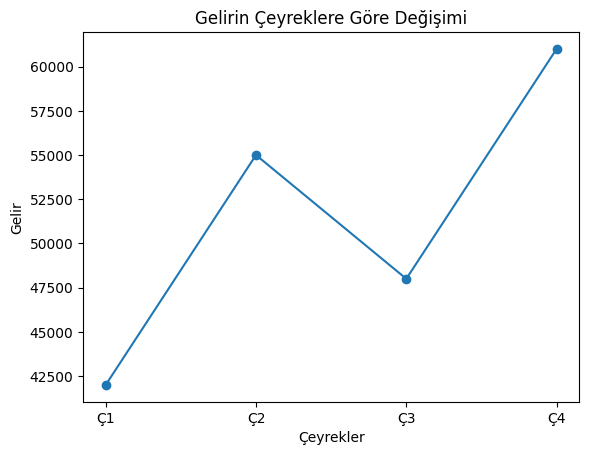

In [41]:
plt.plot(df_gelir['ceyrek'], df_gelir['gelir'], marker="o")
plt.title("Gelirin Çeyreklere Göre Değişimi")
plt.xlabel("Çeyrekler")
plt.ylabel("Gelir")
plt.show()

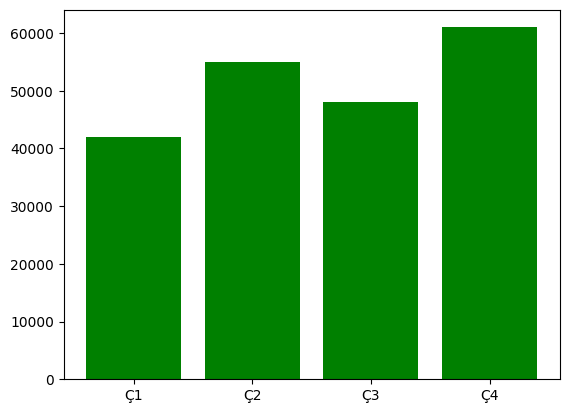

In [42]:
plt.bar(df_gelir['ceyrek'],df_gelir['gelir'], color="green")
plt.show()

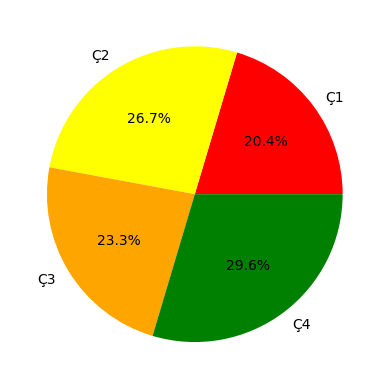

In [43]:
plt.pie(df_gelir['gelir'], colors=["red", "yellow", "orange", "green"], labels=df_gelir['ceyrek'],autopct="%1.1f%%")
plt.show()

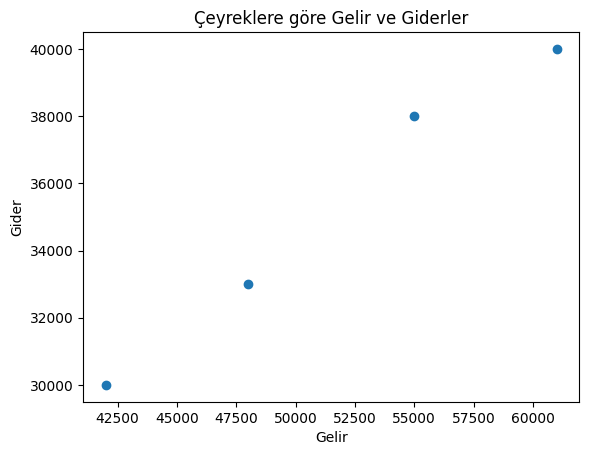

In [44]:
plt.scatter(x=df_gelir['gelir'], y=df_gelir['gider'])
plt.title("Çeyreklere göre Gelir ve Giderler")
plt.xlabel("Gelir")
plt.ylabel("Gider")
plt.show()

Gelirler ile giderler arasında **doğru ilişki** olduğunu görüyoruz.

---## Bonus — Kapsamlı UygulamaBir online kursun satış verisini simüle edin:1. `kurs_adi`, `kategori` (örn. Yazılım, Tasarım, Pazarlama) ve `satis_adedi` sütunlarından oluşan, en az 8 satırlık bir DataFrame oluşturun.2. Kategoriye göre toplam satış adedini `groupby` ile bulun.3. En çok satan 3 kursu `.sort_values()` ile bulun.4. Kategori bazında toplam satışı gösteren bir bar grafik çizin.5. `apply` ile satış adedi 250 üzeri olanlara "Popüler", altındakilere "Standart" yazan yeni bir sütun ekleyin.

In [45]:
data = {
    'kurs_adi': [
        'Pandas ve NumPy ile Veri Analizi', 'İçerik Pazarlaması ve Strateji', 'Proje Yönetimi (PMP)',
        'Sosyal Medya Yönetimi', 'İçerik Pazarlaması ve Strateji', 'Derin Öğrenme ve PyTorch',
        'Google Ads ve SEO Eğitimi', 'Blender ile 3D Modelleme', 'Blender ile 3D Modelleme',
        'Etkili İletişim Teknikleri', 'Figma ile Arayüz Tasarımı', 'Pandas ve NumPy ile Veri Analizi',
        'Sosyal Medya Yönetimi', 'Derin Öğrenme ve PyTorch', 'İçerik Pazarlaması ve Strateji',
        'Derin Öğrenme ve PyTorch', 'Proje Yönetimi (PMP)', 'Etkili İletişim Teknikleri',
        'Blender ile 3D Modelleme', 'Makine Öğrenmesi A-Z', 'UI/UX Tasarım İlkeleri',
        'Zaman Yönetimi ve Verimlilik', 'Power BI ile İş Zekası', 'Pandas ve NumPy ile Veri Analizi',
        'Google Ads ve SEO Eğitimi', 'Makine Öğrenmesi A-Z', 'Makine Öğrenmesi A-Z',
        'Blender ile 3D Modelleme', 'Proje Yönetimi (PMP)', 'Blender ile 3D Modelleme',
        'Figma ile Arayüz Tasarımı', 'Pandas ve NumPy ile Veri Analizi', 'Liderlik ve Takım Yönetimi',
        'Adobe Photoshop Masterclass', 'UI/UX Tasarım İlkeleri'
    ],
    'kategori': [
        'Veri Bilimi', 'Pazarlama', 'Kişisel Gelişim', 'Pazarlama', 'Pazarlama',
        'Veri Bilimi', 'Pazarlama', 'Tasarım', 'Tasarım', 'Kişisel Gelişim',
        'Tasarım', 'Veri Bilimi', 'Pazarlama', 'Veri Bilimi', 'Pazarlama',
        'Veri Bilimi', 'Kişisel Gelişim', 'Kişisel Gelişim', 'Tasarım', 'Veri Bilimi',
        'Tasarım', 'Kişisel Gelişim', 'Veri Bilimi', 'Veri Bilimi', 'Pazarlama',
        'Veri Bilimi', 'Veri Bilimi', 'Tasarım', 'Kişisel Gelişim', 'Tasarım',
        'Tasarım', 'Veri Bilimi', 'Kişisel Gelişim', 'Tasarım', 'Tasarım'
    ],
    'satis_adedi': [
        290, 208, 141, 350, 392, 171, 328, 433, 463, 479,
        272, 68, 189, 483, 74, 150, 154, 186, 108, 261,
        365, 359, 463, 283, 100, 379, 409, 329, 421, 181,
        289, 209, 256, 72, 271
    ]
}

df_satis = pd.DataFrame(data)

In [46]:
kategoriye_gore= pd.DataFrame(df_satis.groupby(by="kategori")["satis_adedi"].sum())
kategoriye_gore

,satis_adedi
kategori,
Kişisel Gelişim,1996
Pazarlama,1641
Tasarım,2783
Veri Bilimi,3166


In [47]:
df_satis.sort_values(by="satis_adedi", ascending=False).head(3)

,kurs_adi,kategori,satis_adedi
13,Derin Öğrenme ve PyTorch,Veri Bilimi,483
9,Etkili İletişim Teknikleri,Kişisel Gelişim,479
8,Blender ile 3D Modelleme,Tasarım,463


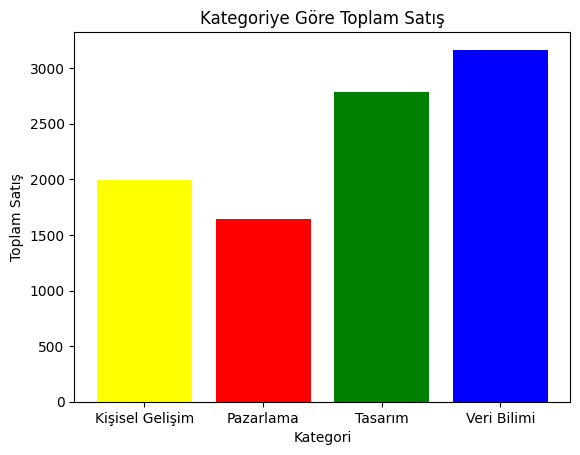

In [48]:
plt.bar(kategoriye_gore.index, kategoriye_gore["satis_adedi"], color=["yellow","red","green","blue"])
plt.title("Kategoriye Göre Toplam Satış")
plt.xlabel("Kategori")
plt.ylabel("Toplam Satış")
plt.show()

In [50]:
df_satis["urun_durum"] = df_satis['satis_adedi'].apply(lambda satis: "Popüler" if satis>250 else "Standart")
df_satis

,kurs_adi,kategori,satis_adedi,urun_durum
0,Pandas ve NumPy ile Veri Analizi,Veri Bilimi,290,Popüler
1,İçerik Pazarlaması ve Strateji,Pazarlama,208,Standart
2,Proje Yönetimi (PMP),Kişisel Gelişim,141,Standart
3,Sosyal Medya Yönetimi,Pazarlama,350,Popüler
4,İçerik Pazarlaması ve Strateji,Pazarlama,392,Popüler
5,Derin Öğrenme ve PyTorch,Veri Bilimi,171,Standart
6,Google Ads ve SEO Eğitimi,Pazarlama,328,Popüler
7,Blender ile 3D Modelleme,Tasarım,433,Popüler
8,Blender ile 3D Modelleme,Tasarım,463,Popüler
9,Etkili İletişim Teknikleri,Kişisel Gelişim,479,Popüler
